In [28]:
import xarray as xr
import xskillscore
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.io.shapereader
from scipy import stats
import re

os.makedirs("figures/RPSS drivers", exist_ok=True)


## Load and align data

In [29]:
obs_unet = xr.open_dataarray('outputs/Full Period/GEFS_IMD/unet_ytest_raw_wk3-4.nc')
obs_ohe  = xr.open_dataarray('outputs/Full Period/GEFS_IMD/unet_y_test_wk3-4.nc')
preds    = xr.open_dataarray('outputs/Full Period/GEFS_IMD/unet_predictions_wk3-4.nc')
preds_elr = xr.open_dataarray('outputs/Full Period/GEFS_IMD/ELR_predictions_wk3-4.nc')

# obs_unet: (bootstrap, T=396, Y, X) — raw labels, real datetime T coords
# obs_ohe:  (bootstrap, T=66,  Y, X, category) — one-hot, integer T index
# preds:    (bootstrap, T=66,  Y, X, category) — probabilities, integer T index

# Recover real datetime T coords for obs_ohe / preds from obs_unet
valid_T_per_bootstrap = {}
for b in obs_unet.bootstrap.values:
    da = obs_unet.sel(bootstrap=b)
    valid = ~da.isnull().all(dim=("Y", "X"))
    valid_T_per_bootstrap[b] = da['T'][valid].values

# Assign real T coords and average over bootstraps
obs_ohe_list, preds_list = [], []
for b in range(len(obs_unet.bootstrap)):
    valid_T = valid_T_per_bootstrap[b]
    obs_ohe_list.append(obs_ohe.sel(bootstrap=b).assign_coords(T=valid_T))
    preds_list.append(preds.sel(bootstrap=b).assign_coords(T=valid_T))

obs_oheM  = xr.concat(obs_ohe_list, dim="bootstrap").mean(dim="bootstrap")   # (T, Y, X, cat)
preds_M   = xr.concat(preds_list,   dim="bootstrap").mean(dim="bootstrap")   # (T, Y, X, cat)
obs_unetM = obs_unet.mean(dim="bootstrap")                                    # (T, Y, X)

# Remove all-NaN time steps
valid_t = ~obs_oheM.isnull().all(dim=("Y","X","category"))
obs_oheM  = obs_oheM.sel(T=valid_t)
preds_M   = preds_M.sel(T=valid_t)

# Assign real lat/lon coords (obs_ohe uses integer indices, obs_unet has real coords)
real_X = obs_unet.X
real_Y = obs_unet.Y
obs_oheM  = obs_oheM.assign_coords(X=real_X, Y=real_Y)
preds_M   = preds_M.assign_coords(X=real_X, Y=real_Y)

land_mask = preds_elr.isel(bootstrap=0, category=0).isnull().all(dim='T')
land_mask = land_mask.assign_coords(X=real_X, Y=real_Y)

print("obs_oheM shape:", obs_oheM.shape)
print("preds_M  shape:", preds_M.shape)
print("T range:", str(obs_oheM.T.values[0])[:10], "to", str(obs_oheM.T.values[-1])[:10])


obs_oheM shape: (396, 32, 32, 3)
preds_M  shape: (396, 32, 32, 3)
T range: [[[0. 0. 0 to [[[0. 0. 0


## RPSS — aggregated formulation (consistent with `tune_GEFS_full`)

`xskillscore.rps` with `dim='T'` sums RPS over all dates before dividing:
$$\text{RPSS}(\mathbf{x}) = 1 - \frac{\sum_t \text{RPS}_t(\mathbf{x})}{\sum_t \text{RPS}^{\text{clim}}_t(\mathbf{x})}$$


In [30]:
# obs_ohe is already one-hot (0/1); xskillscore expects (T, Y, X, category)
obs_r  = obs_oheM.transpose('T','Y','X','category')   # one-hot obs
fcast  = preds_M.transpose('T','Y','X','category')    # model forecast

# Climatological forecast: 1/3 per category, same shape as fcast
climo  = xr.full_like(fcast, 1/3)

rps_model = xskillscore.rps(obs_r, fcast,  dim='T', category_edges=None, input_distributions='p')
rps_climo = xskillscore.rps(obs_r, climo,  dim='T', category_edges=None, input_distributions='p')

rpss = (1 - rps_model / rps_climo).where(~land_mask).assign_coords(X=real_X, Y=real_Y)

print("RPSS range:", float(rpss.min().values), "to", float(rpss.max().values))


RPSS range: -0.01830663428770407 to 0.16474343229383615


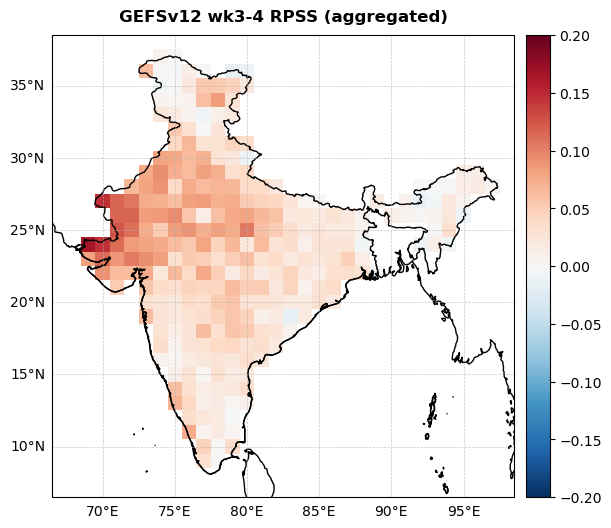

In [31]:
def plot_map(da, title="", cmap="RdBu_r", vmin=-0.2, vmax=0.2):
    fig, ax = plt.subplots(figsize=(8,6), subplot_kw={'projection': ccrs.PlateCarree()})
    im = da.plot(ax=ax, transform=ccrs.PlateCarree(), cmap=cmap,
                 vmin=vmin, vmax=vmax, add_colorbar=False)
    ax.coastlines()
    reader = cartopy.io.shapereader.Reader('shapes/indian_borders.shp')
    ax.add_geometries(reader.geometries(), ccrs.PlateCarree(),
                      facecolor='none', edgecolor='black')
    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)
    gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, alpha=0.7)
    gl.top_labels = False; gl.right_labels = False
    plt.colorbar(im, ax=ax, orientation="vertical", pad=0.02, fraction=0.05)
    plt.show()

plot_map(rpss, title="GEFSv12 wk3-4 RPSS (aggregated)")


# MJO

In [32]:
mjo = pd.read_csv(
    "download/mjo.txt", skiprows=2, sep=r'\s+', header=None,
    names=["year","month","day","RMM1","RMM2","phase","amplitude","method","extra"],
    na_values=[1e35, 999]
).drop(columns="extra", errors="ignore")
mjo["date"] = pd.to_datetime(dict(year=mjo.year, month=mjo.month, day=mjo.day), errors="coerce")
mjo = mjo[(mjo['date'] >= '1980-01-01') & (mjo['date'] <= '2025-12-31')].set_index('date')

df_mjo_roll = mjo[['RMM1','RMM2']].rolling(window=15, center=True, min_periods=1).mean()
mjo_xr = df_mjo_roll.to_xarray()

rpss_dates = pd.to_datetime(obs_oheM['T'].values)
rmm1 = mjo_xr['RMM1'].sel(date=rpss_dates, method='nearest').values
rmm2 = mjo_xr['RMM2'].sel(date=rpss_dates, method='nearest').values
phase_num = (((np.arctan2(rmm2, rmm1) + 2*np.pi) % (2*np.pi)) // (np.pi/4) + 1).astype(int)
phase_da  = xr.DataArray(phase_num, dims=('T',), coords={'T': obs_oheM['T']})
print("Phase counts:", {int(p): int((phase_da==p).sum()) for p in range(1,9)})


Phase counts: {1: 46, 2: 54, 3: 38, 4: 47, 5: 72, 6: 62, 7: 37, 8: 40}


## RPSS per MJO phase

In [33]:
rpss_mjo = {}
for phase in range(1, 9):
    mask_t = (phase_da == phase).values
    if mask_t.sum() < 3:
        continue
    obs_ph  = obs_r.isel(T=mask_t)
    fcast_ph = fcast.isel(T=mask_t)
    climo_ph = climo.isel(T=mask_t)
    rps_m = xskillscore.rps(obs_ph, fcast_ph, dim='T', category_edges=None, input_distributions='p')
    rps_c = xskillscore.rps(obs_ph, climo_ph, dim='T', category_edges=None, input_distributions='p')
    rpss_mjo[phase] = (1 - rps_m / rps_c).where(~land_mask)

print("Phases computed:", list(rpss_mjo.keys()))


Phases computed: [1, 2, 3, 4, 5, 6, 7, 8]


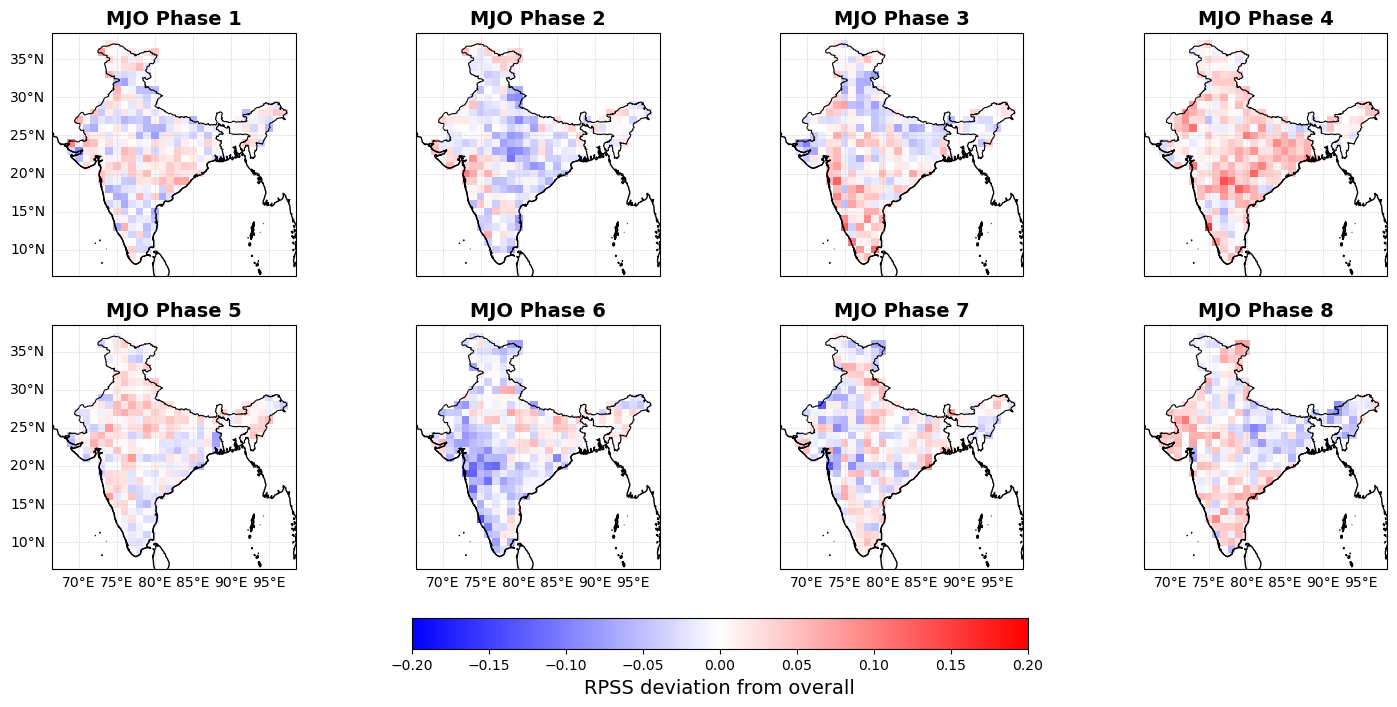

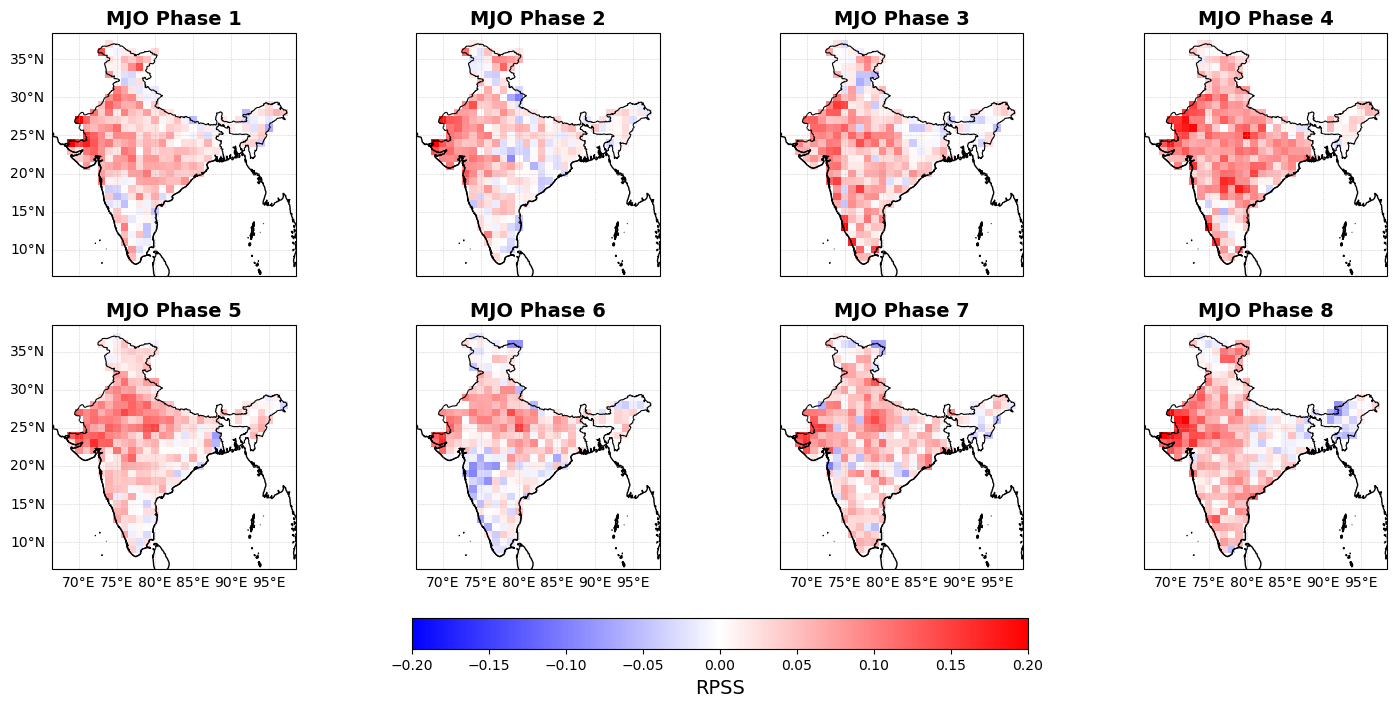

In [34]:
def plot_mjo_phases(rpss_dict, demean=True, rpss_ref=None,
                   vmin=-0.2, vmax=0.2, cmap='bwr', fname=None):
    if rpss_ref is None:
        rpss_ref = rpss
    fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(18,8),
                             subplot_kw={"projection": ccrs.PlateCarree()})
    axes = axes.flatten(); mappable = None

    for i, phase in enumerate(range(1,9)):
        ax  = axes[i]
        val = rpss_dict[phase]
        if demean:
            val = val - rpss_ref
        im = val.plot(ax=ax, transform=ccrs.PlateCarree(),
                      cmap=cmap, vmin=vmin, vmax=vmax, add_colorbar=False)
        if mappable is None: mappable = im
        ax.coastlines()
        reader = cartopy.io.shapereader.Reader('shapes/indian_borders.shp')
        ax.add_geometries(reader.geometries(), ccrs.PlateCarree(),
                          facecolor='none', edgecolor='black', linewidth=0.8)
        ax.set_title(f"MJO Phase {phase}", fontsize=14, fontweight="bold", pad=6)
        gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.4, alpha=0.6)
        gl.top_labels = False; gl.right_labels = False
        if i % 4 != 0: gl.left_labels = False
        if i < 4:      gl.bottom_labels = False
        gl.xlabel_style = {"size":10}; gl.ylabel_style = {"size":10}

    cbar = fig.colorbar(mappable, ax=axes, orientation="horizontal", fraction=0.05, pad=0.08)
    cbar.set_label("RPSS deviation from overall" if demean else "RPSS", fontsize=14)
    if fname:
        plt.savefig(f"figures/RPSS drivers/{fname}", dpi=300, bbox_inches="tight")
    plt.show()

plot_mjo_phases(rpss_mjo, demean=True,  fname="RPSS_MJO_deviation.pdf")
plot_mjo_phases(rpss_mjo, demean=False, vmin=-0.2, vmax=0.2, fname="RPSS_MJO_plain.pdf")


## MJO composite maps with stippling (phase vs all, p < 0.10)

C:\Users\emile\AppData\Local\Temp\ipykernel_14800\1901015177.py:12: RuntimeWarning: Mean of empty slice
  ma, mb = np.nanmean(a, axis=0), np.nanmean(b, axis=0)
c:\Users\emile\anaconda3\envs\s2s-cnn\lib\site-packages\numpy\lib\_nanfunctions_impl.py:2053: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\emile\AppData\Local\Temp\ipykernel_14800\1901015177.py:12: RuntimeWarning: Mean of empty slice
  ma, mb = np.nanmean(a, axis=0), np.nanmean(b, axis=0)
c:\Users\emile\anaconda3\envs\s2s-cnn\lib\site-packages\numpy\lib\_nanfunctions_impl.py:2053: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\emile\AppData\Local\Temp\ipykernel_14800\1901015177.py:12: RuntimeWarning: Mean of empty slice
  ma, mb = np.nanmean(a, axis=0), np.nanmean(b, axis=0)
c:\Users\emile\anaconda3\envs\s2s-cnn\lib\site-packages\numpy\lib\_nanfunctions_impl.py:2053: RuntimeWarni

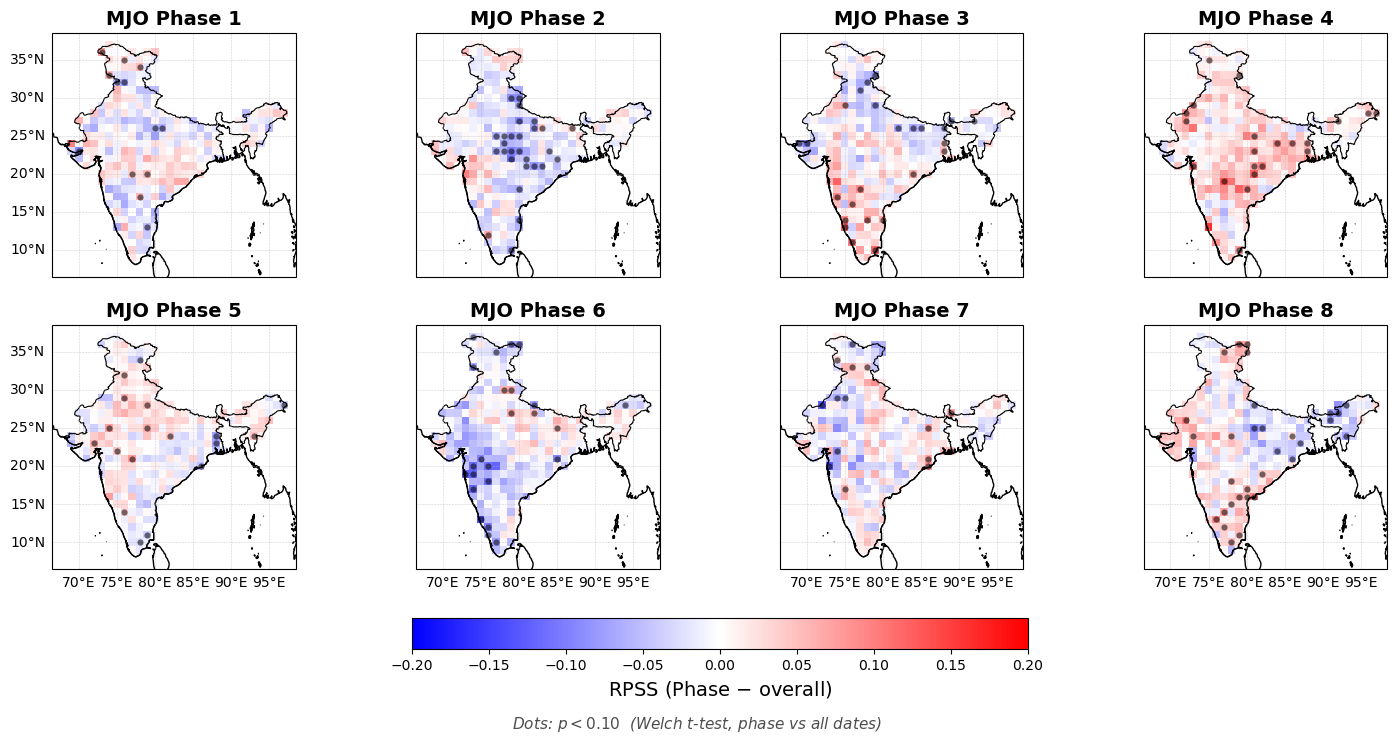

In [35]:
# Per-date RPS for t-test (manual CDF difference)
fc_cdf   = fcast.cumsum(dim="category")
obs_cdf  = obs_r.cumsum(dim="category")
climo_cdf = climo.cumsum(dim="category")
rps_per_t       = ((fc_cdf  - obs_cdf)**2).sum(dim="category")        # (T,Y,X)
rps_climo_per_t = ((climo_cdf - obs_cdf)**2).sum(dim="category")      # (T,Y,X)
rpss_per_t = (1 - rps_per_t / rps_climo_per_t).where(~land_mask)

def ttest_2samp_grid(a, b):
    na  = (~np.isnan(a)).sum(axis=0)
    nb_ = (~np.isnan(b)).sum(axis=0)
    ma, mb = np.nanmean(a, axis=0), np.nanmean(b, axis=0)
    sa = np.nanstd(a, axis=0, ddof=1)**2 / np.maximum(na,  1)
    sb = np.nanstd(b, axis=0, ddof=1)**2 / np.maximum(nb_, 1)
    se = np.sqrt(sa + sb)
    t  = (ma - mb) / np.where(se > 0, se, np.nan)
    df = (sa + sb)**2 / (sa**2 / np.maximum(na-1,1) + sb**2 / np.maximum(nb_-1,1))
    p  = 2 * stats.t.sf(np.abs(t), df=df)
    return np.where((na < 3) | (nb_ < 3), np.nan, p)

rpss_vals = rpss_per_t.values   # (T, Y, X)

mjo_pval = {}
for phase in range(1, 9):
    mask_t = (phase_da == phase).values
    mjo_pval[phase] = xr.DataArray(
        ttest_2samp_grid(rpss_vals[mask_t], rpss_vals),
        dims=["Y","X"], coords={"Y": rpss.Y, "X": rpss.X}
    )

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(18,8),
                         subplot_kw={"projection": ccrs.PlateCarree()})
axes = axes.flatten(); mappable = None

for i, phase in enumerate(range(1,9)):
    ax   = axes[i]
    diff = rpss_mjo[phase] - rpss
    im   = diff.plot(ax=ax, transform=ccrs.PlateCarree(),
                     cmap='bwr', vmin=-0.2, vmax=0.2, add_colorbar=False)
    if mappable is None: mappable = im

    pv = mjo_pval[phase]
    sig = (pv < 0.10).values
    lon2d, lat2d = np.meshgrid(pv["X"].values, pv["Y"].values)
    ax.scatter(lon2d[sig], lat2d[sig], s=20, c="black", alpha=0.55,
               linewidths=0, transform=ccrs.PlateCarree(), zorder=5)

    ax.coastlines()
    reader = cartopy.io.shapereader.Reader('shapes/indian_borders.shp')
    ax.add_geometries(reader.geometries(), ccrs.PlateCarree(),
                      facecolor='none', edgecolor='black', linewidth=0.8)
    ax.set_title(f"MJO Phase {phase}", fontsize=14, fontweight="bold", pad=6)
    gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.4, alpha=0.6)
    gl.top_labels = False; gl.right_labels = False
    if i % 4 != 0: gl.left_labels = False
    if i < 4:      gl.bottom_labels = False
    gl.xlabel_style = {"size":10}; gl.ylabel_style = {"size":10}

cbar = fig.colorbar(mappable, ax=axes, orientation="horizontal", fraction=0.05, pad=0.08)
cbar.set_label("RPSS (Phase $-$ overall)", fontsize=14)
fig.text(0.5, 0.01, r"Dots: $p < 0.10$  (Welch t-test, phase vs all dates)",
         ha="center", fontsize=11, style="italic", color="0.3")
plt.savefig("figures/RPSS drivers/RPSS_MJO_composite_sig.pdf", dpi=300, bbox_inches="tight")
plt.show()


# ENSO

In [36]:
records = []
pattern = re.compile(r"[+-]?\d+\.\d+")
with open("download/sst_weekly.txt") as f:
    for line in f:
        if re.match(r"\s*\d{2}[A-Z]{3}\d{4}", line):
            date = line.split()[0]
            nums = list(map(float, pattern.findall(line)))
            if len(nums) == 8:
                records.append([date] + nums)

cols = ["Week","Nino12_SST","Nino12_SSTA","Nino3_SST","Nino3_SSTA",
        "Nino34_SST","Nino34_SSTA","Nino4_SST","Nino4_SSTA"]
nino = pd.DataFrame(records, columns=cols)
nino["Week"] = pd.to_datetime(nino["Week"], format="%d%b%Y")
nino = nino.set_index("Week").rolling(window=2, center=True, min_periods=1).mean()
nino_xr = nino.to_xarray()

nino4_vals  = nino_xr["Nino4_SSTA"].sel(Week=rpss_dates, method="nearest").values
nino4_vals = nino_xr["Nino4_SSTA"].sel(Week=rpss_dates, method="nearest").values

enso4_da  = xr.DataArray(xr.where(xr.DataArray(nino4_vals,  dims='T') >=  0.5, 1,
                          xr.where(xr.DataArray(nino4_vals,  dims='T') <= -0.5, -1, 0)).values,
                         dims=('T',), coords={'T': obs_oheM['T']})
enso4_da = xr.DataArray(xr.where(xr.DataArray(nino4_vals, dims='T') >=  0.5, 1,
                          xr.where(xr.DataArray(nino4_vals, dims='T') <= -0.5, -1, 0)).values,
                         dims=('T',), coords={'T': obs_oheM['T']})

print("ENSO4  counts:", {int(v): int((enso4_da ==v).sum()) for v in [-1,0,1]})
print("ENSO4 counts:", {int(v): int((enso4_da==v).sum()) for v in [-1,0,1]})


ENSO4  counts: {-1: 59, 0: 278, 1: 59}
ENSO4 counts: {-1: 59, 0: 278, 1: 59}


## RPSS per ENSO mode + composite stippling maps

In [37]:
def rpss_by_enso(mode_da):
    out = {}
    for mode in [-1, 0, 1]:
        mask_t = (mode_da == mode).values
        if mask_t.sum() < 3: continue
        rps_m = xskillscore.rps(obs_r.isel(T=mask_t), fcast.isel(T=mask_t),
                                dim='T', category_edges=None, input_distributions='p')
        rps_c = xskillscore.rps(obs_r.isel(T=mask_t), climo.isel(T=mask_t),
                                dim='T', category_edges=None, input_distributions='p')
        out[mode] = (1 - rps_m / rps_c).where(~land_mask)
    return out

rpss_enso4  = rpss_by_enso(enso4_da)
rpss_enso4 = rpss_by_enso(enso4_da)
print("Done.")


Done.


C:\Users\emile\AppData\Local\Temp\ipykernel_14800\1901015177.py:12: RuntimeWarning: Mean of empty slice
  ma, mb = np.nanmean(a, axis=0), np.nanmean(b, axis=0)
c:\Users\emile\anaconda3\envs\s2s-cnn\lib\site-packages\numpy\lib\_nanfunctions_impl.py:2053: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\emile\AppData\Local\Temp\ipykernel_14800\1901015177.py:12: RuntimeWarning: Mean of empty slice
  ma, mb = np.nanmean(a, axis=0), np.nanmean(b, axis=0)
c:\Users\emile\anaconda3\envs\s2s-cnn\lib\site-packages\numpy\lib\_nanfunctions_impl.py:2053: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\emile\AppData\Local\Temp\ipykernel_14800\1901015177.py:12: RuntimeWarning: Mean of empty slice
  ma, mb = np.nanmean(a, axis=0), np.nanmean(b, axis=0)
c:\Users\emile\anaconda3\envs\s2s-cnn\lib\site-packages\numpy\lib\_nanfunctions_impl.py:2053: RuntimeWarni

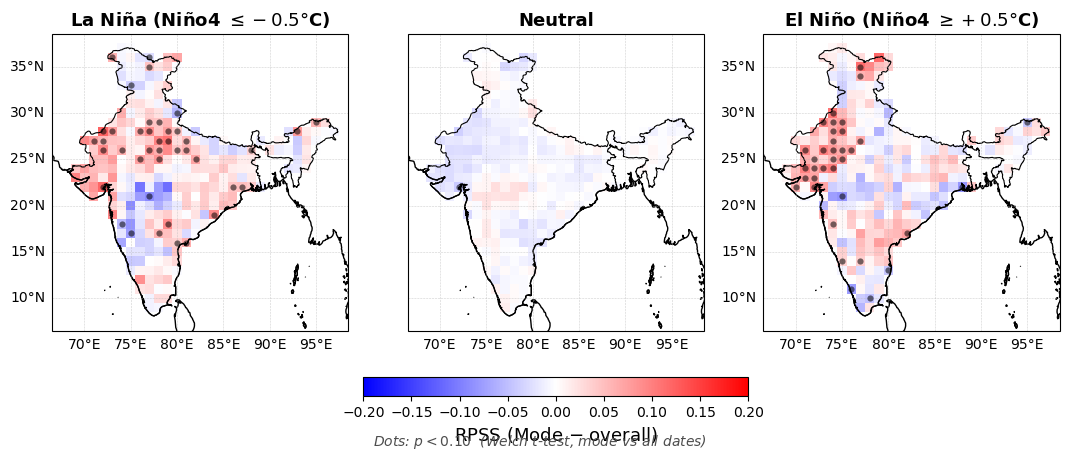

C:\Users\emile\AppData\Local\Temp\ipykernel_14800\1901015177.py:12: RuntimeWarning: Mean of empty slice
  ma, mb = np.nanmean(a, axis=0), np.nanmean(b, axis=0)
c:\Users\emile\anaconda3\envs\s2s-cnn\lib\site-packages\numpy\lib\_nanfunctions_impl.py:2053: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\emile\AppData\Local\Temp\ipykernel_14800\1901015177.py:12: RuntimeWarning: Mean of empty slice
  ma, mb = np.nanmean(a, axis=0), np.nanmean(b, axis=0)
c:\Users\emile\anaconda3\envs\s2s-cnn\lib\site-packages\numpy\lib\_nanfunctions_impl.py:2053: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\emile\AppData\Local\Temp\ipykernel_14800\1901015177.py:12: RuntimeWarning: Mean of empty slice
  ma, mb = np.nanmean(a, axis=0), np.nanmean(b, axis=0)
c:\Users\emile\anaconda3\envs\s2s-cnn\lib\site-packages\numpy\lib\_nanfunctions_impl.py:2053: RuntimeWarni

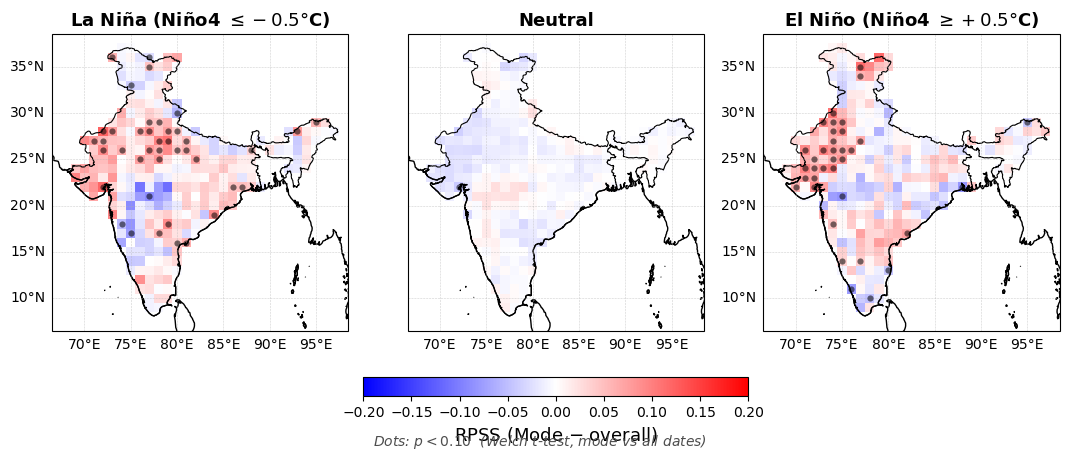

In [38]:
def plot_enso_sig(rpss_enso, mode_da, titles, fname, alpha=0.10):
    # t-test
    enso_pval = {}
    for mode in [-1, 0, 1]:
        mask_t = (mode_da == mode).values
        enso_pval[mode] = xr.DataArray(
            ttest_2samp_grid(rpss_vals[mask_t], rpss_vals),
            dims=["Y","X"], coords={"Y": rpss.Y, "X": rpss.X}
        )

    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(13,5),
                             subplot_kw={"projection": ccrs.PlateCarree()})
    mappable = None

    for i, mode in enumerate([-1, 0, 1]):
        ax   = axes[i]
        diff = rpss_enso[mode] - rpss
        im   = diff.plot(ax=ax, transform=ccrs.PlateCarree(),
                         cmap='bwr', vmin=-0.2, vmax=0.2, add_colorbar=False)
        if mappable is None: mappable = im

        pv  = enso_pval[mode]
        sig = (pv < alpha).values
        lon2d, lat2d = np.meshgrid(pv["X"].values, pv["Y"].values)
        ax.scatter(lon2d[sig], lat2d[sig], s=20, c="black", alpha=0.55,
                   linewidths=0, transform=ccrs.PlateCarree(), zorder=5)

        ax.coastlines()
        reader = cartopy.io.shapereader.Reader('shapes/indian_borders.shp')
        ax.add_geometries(reader.geometries(), ccrs.PlateCarree(),
                          facecolor='none', edgecolor='black', linewidth=0.8)
        ax.set_title(titles[mode], fontsize=13, fontweight="bold", pad=6)
        gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.4, alpha=0.6)
        gl.top_labels = False; gl.right_labels = False
        if i == 1: gl.left_labels = False
        gl.xlabel_style = {"size":10}; gl.ylabel_style = {"size":10}

    cbar = fig.colorbar(mappable, ax=axes, orientation="horizontal", fraction=0.05, pad=0.12)
    cbar.set_label("RPSS (Mode $-$ overall)", fontsize=13)
    fig.text(0.5, 0.01, r"Dots: $p < 0.10$  (Welch t-test, mode vs all dates)",
             ha="center", fontsize=10, style="italic", color="0.3")
    plt.savefig(f"figures/RPSS drivers/{fname}", dpi=300, bbox_inches="tight")
    plt.show()

nino4_titles  = {-1: r"La Niña (Niño4 $\leq -0.5°$C)",  0: "Neutral",
                  1: r"El Niño (Niño4 $\geq +0.5°$C)"}
nino4_titles = {-1: r"La Niña (Niño4 $\leq -0.5°$C)", 0: "Neutral",
                  1: r"El Niño (Niño4 $\geq +0.5°$C)"}

plot_enso_sig(rpss_enso4,  enso4_da,  nino4_titles,  "RPSS_ENSO4_composite_sig.pdf")
plot_enso_sig(rpss_enso4, enso4_da, nino4_titles, "RPSS_ENSO4_composite_sig.pdf")


## Plain RPSS per ENSO mode (Niño4 and Niño3.4)

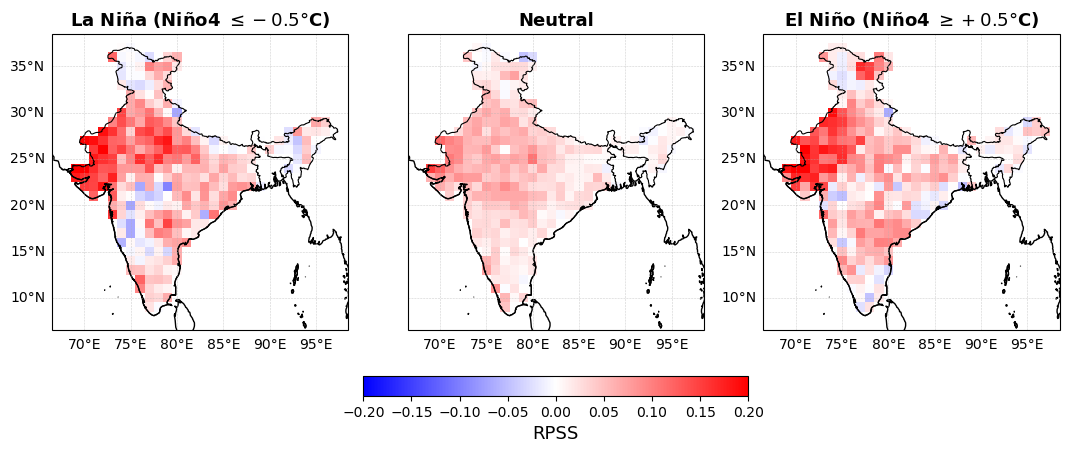

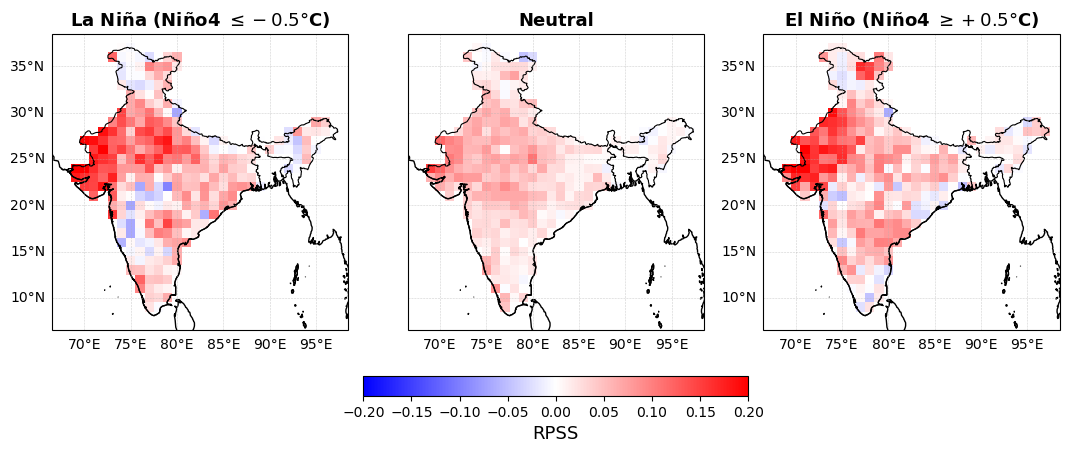

In [39]:
def plot_enso_plain(rpss_enso, titles, fname):
    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(13, 5),
                             subplot_kw={"projection": ccrs.PlateCarree()})
    mappable = None

    for i, mode in enumerate([-1, 0, 1]):
        ax  = axes[i]
        val = rpss_enso[mode]

        im = val.plot(ax=ax, transform=ccrs.PlateCarree(),
                      cmap='bwr', vmin=-0.2, vmax=0.2, add_colorbar=False)
        if mappable is None:
            mappable = im

        ax.coastlines()
        reader = cartopy.io.shapereader.Reader('shapes/indian_borders.shp')
        ax.add_geometries(reader.geometries(), ccrs.PlateCarree(),
                          facecolor='none', edgecolor='black', linewidth=0.8)
        ax.set_title(titles[mode], fontsize=13, fontweight="bold", pad=6)

        gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.4, alpha=0.6)
        gl.top_labels = False; gl.right_labels = False
        if i == 1: gl.left_labels = False
        gl.xlabel_style = {"size": 10}; gl.ylabel_style = {"size": 10}

    cbar = fig.colorbar(mappable, ax=axes, orientation="horizontal",
                        fraction=0.05, pad=0.12)
    cbar.set_label("RPSS", fontsize=13)
    plt.savefig(f"figures/RPSS drivers/{fname}", dpi=300, bbox_inches="tight")
    plt.show()

nino4_titles  = {-1: r"La Niña (Niño4 $\leq -0.5°$C)",  0: "Neutral",
                  1: r"El Niño (Niño4 $\geq +0.5°$C)"}
nino4_titles = {-1: r"La Niña (Niño4 $\leq -0.5°$C)", 0: "Neutral",
                  1: r"El Niño (Niño4 $\geq +0.5°$C)"}

plot_enso_plain(rpss_enso4,  nino4_titles,  "RPSS_ENSO4_plain.pdf")
plot_enso_plain(rpss_enso4, nino4_titles, "RPSS_ENSO4_plain.pdf")


## Box plots with significance stars

C:\Users\emile\AppData\Local\Temp\ipykernel_14800\3068496578.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_enso, x="Category", y="RPSS",
C:\Users\emile\AppData\Local\Temp\ipykernel_14800\3068496578.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_mjo, x="Category", y="RPSS",
C:\Users\emile\AppData\Local\Temp\ipykernel_14800\3068496578.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


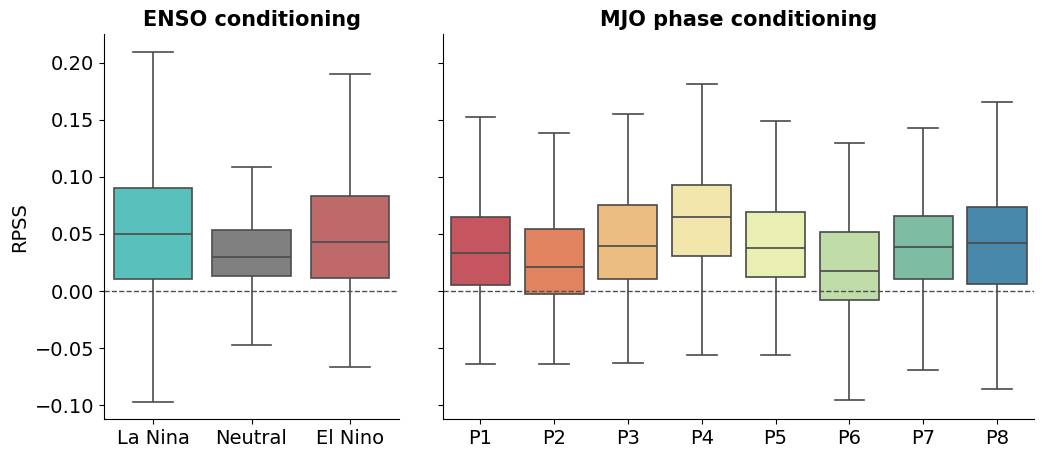

In [40]:
rows_mjo, rows_enso = [], []
for phase in range(1, 9):
    vals = rpss_mjo[phase].values.ravel()
    for v in vals[~np.isnan(vals)]:
        rows_mjo.append({"Category": f"P{phase}", "RPSS": v})

for mode, lb in [(-1, "La Nina"), (0, "Neutral"), (1, "El Nino")]:
    vals = rpss_enso4[mode].values.ravel()
    for v in vals[~np.isnan(vals)]:
        rows_enso.append({"Category": lb, "RPSS": v})

df_mjo  = pd.DataFrame(rows_mjo)
df_enso = pd.DataFrame(rows_enso)

fig, axes = plt.subplots(ncols=2, figsize=(12, 5), sharey=True,
                         gridspec_kw={"width_ratios": [1, 2], "wspace": 0.1})

sns.boxplot(data=df_enso, x="Category", y="RPSS",
            order=["La Nina", "Neutral", "El Nino"],
            palette=['mediumturquoise', 'gray', 'indianred'],
            showfliers=False, ax=axes[0], linewidth=1.2)
axes[0].set_title("ENSO conditioning", fontweight="bold", fontsize=15)
axes[0].set_xlabel("")
axes[0].set_ylabel("RPSS", fontsize=14)

sns.boxplot(data=df_mjo, x="Category", y="RPSS",
            palette=sns.color_palette("Spectral", 8),
            showfliers=False, ax=axes[1], linewidth=1.2)
axes[1].set_title("MJO phase conditioning", fontweight="bold", fontsize=15)
axes[1].set_xlabel("")
axes[1].set_ylabel("")

for ax in axes:
    ax.axhline(0, color="0.3", linestyle="--", linewidth=1)
    ax.tick_params(axis="x", labelsize=14, rotation=0)
axes[0].tick_params(axis="y", labelsize=14)

sns.despine()
plt.tight_layout()
plt.savefig("figures/RPSS drivers/RPSS_MJO_ENSO_boxplot.pdf", dpi=300, bbox_inches="tight")
plt.show()


C:\Users\emile\AppData\Local\Temp\ipykernel_14800\2570423949.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


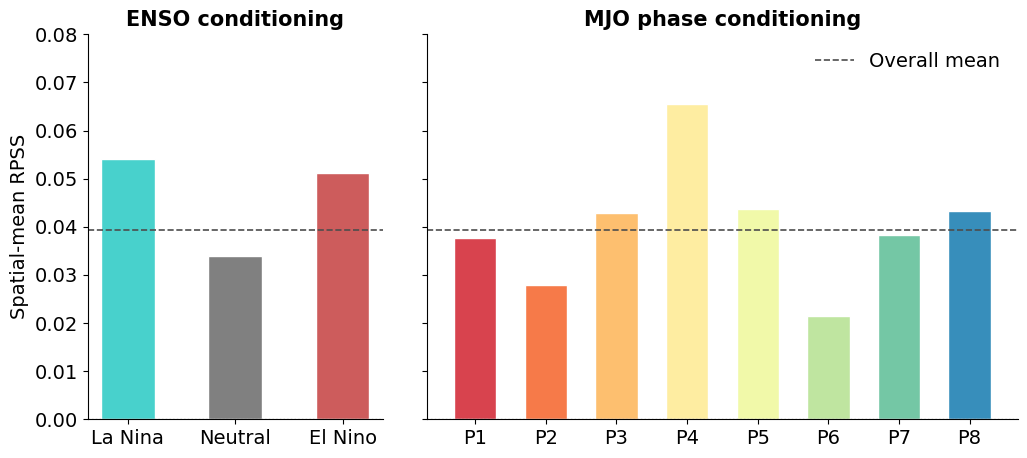

In [41]:
# Spatial-mean RPSS per condition — boxplot of grid-point values, one box per condition
rows_mjo_sp, rows_enso_sp = [], []
for phase in range(1, 9):
    rows_mjo_sp.append({"Category": f"P{phase}", "RPSS": float(rpss_mjo[phase].mean().values)})

for mode, lb in [(-1, "La Nina"), (0, "Neutral"), (1, "El Nino")]:
    rows_enso_sp.append({"Category": lb, "RPSS": float(rpss_enso4[mode].mean().values)})

df_mjo_sp  = pd.DataFrame(rows_mjo_sp)
df_enso_sp = pd.DataFrame(rows_enso_sp)

fig, axes = plt.subplots(ncols=2, figsize=(12, 5), sharey=True,
                         gridspec_kw={"width_ratios": [1, 2], "wspace": 0.1})

enso_order  = ["La Nina", "Neutral", "El Nino"]
enso_colors = ['mediumturquoise', 'gray', 'indianred']
mjo_colors  = sns.color_palette("Spectral", 8)

# ENSO bars
axes[0].bar(enso_order, df_enso_sp["RPSS"], color=enso_colors, edgecolor='white', width=0.5)
axes[0].axhline(float(rpss.mean().values), color='0.3', ls='--', lw=1.2, label='Overall mean')
axes[0].set_title("ENSO conditioning", fontweight="bold", fontsize=15)
axes[0].set_ylabel("Spatial-mean RPSS", fontsize=14)
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", labelsize=14)
#axes[0].legend(fontsize=9, frameon=False)

# MJO bars
axes[1].bar(df_mjo_sp["Category"], df_mjo_sp["RPSS"], color=mjo_colors, edgecolor='white', width=0.6)
axes[1].axhline(float(rpss.mean().values), color='0.3', ls='--', lw=1.2, label='Overall mean')
axes[1].set_title("MJO phase conditioning", fontweight="bold", fontsize=15)
axes[1].set_xlabel("")
axes[1].set_ylabel("")
axes[1].tick_params(axis="x", labelsize=14)
axes[1].legend(fontsize=14, frameon=False)

for ax in axes:
    ax.axhline(0, color='0.7', ls=':', lw=1)
    ax.set_ylim(0, 0.08)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis="y", labelsize=14)

plt.tight_layout()
plt.savefig("figures/RPSS drivers/RPSS_MJO_ENSO_barchart.pdf", dpi=300, bbox_inches="tight")
plt.show()


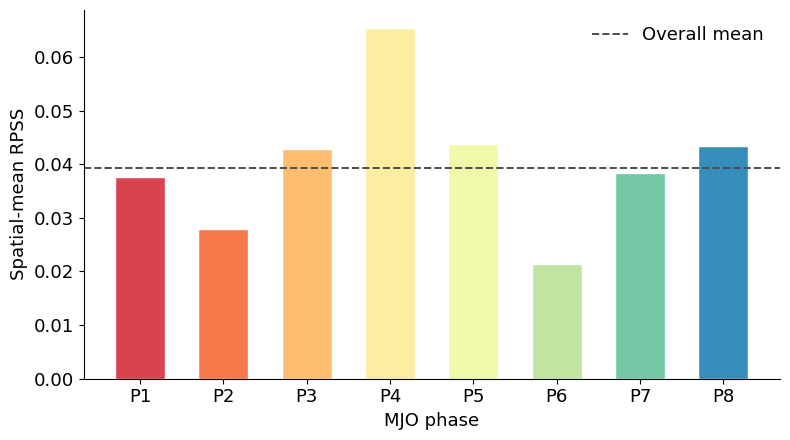

In [42]:
# MJO-only bar chart (spatial-mean RPSS per phase, no ENSO stratification)
mjo_means  = [float(rpss_mjo[ph].mean().values) for ph in range(1, 9)]
overall_mean = float(rpss.mean().values)
mjo_colors = sns.color_palette("Spectral", 8)

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(range(1, 9), mjo_means, color=mjo_colors, edgecolor='white', width=0.6)
ax.axhline(overall_mean, color='0.3', ls='--', lw=1.4, label=f'Overall mean')
ax.set_xticks(range(1, 9))
ax.set_xticklabels([f"P{p}" for p in range(1, 9)], fontsize=13)
ax.set_xlabel("MJO phase", fontsize=13)
ax.set_ylabel("Spatial-mean RPSS", fontsize=13)
#ax.set_title("RPSS stratified by MJO phase", fontsize=13, fontweight="bold")
ax.tick_params(axis="y", labelsize=13)
ax.legend(fontsize=13, frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig("figures/RPSS drivers/RPSS_MJO_barchart.pdf", dpi=300, bbox_inches="tight")
plt.show()


C:\Users\emile\AppData\Local\Temp\ipykernel_14800\2668742509.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


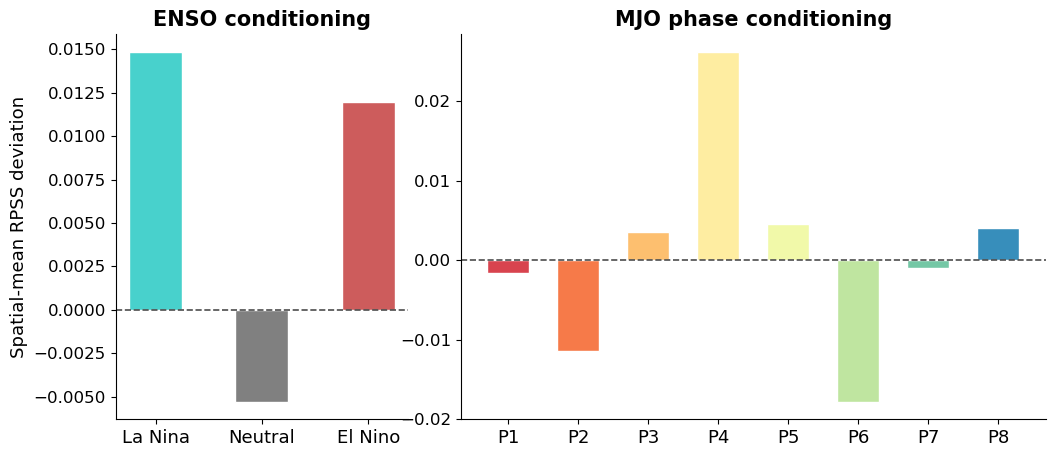

In [43]:
# Combined MJO + ENSO bar chart using RPSS deviation from grid-point mean
# Deviation = rpss_condition(Y,X) - rpss(Y,X), then spatial mean

enso_order  = ["La Nina", "Neutral", "El Nino"]
enso_colors = ['mediumturquoise', 'gray', 'indianred']
mjo_colors  = sns.color_palette("Spectral", 8)

enso_dev_means = {}
for mode, lb in [(-1, "La Nina"), (0, "Neutral"), (1, "El Nino")]:
    dev = rpss_enso4[mode] - rpss
    enso_dev_means[lb] = float(dev.mean().values)

mjo_dev_means = []
for ph in range(1, 9):
    dev = rpss_mjo[ph] - rpss
    mjo_dev_means.append(float(dev.mean().values))

fig, axes = plt.subplots(ncols=2, figsize=(12, 5),
                         gridspec_kw={"width_ratios": [1, 2], "wspace": 0.12})

# ENSO panel
axes[0].bar(enso_order, [enso_dev_means[lb] for lb in enso_order],
            color=enso_colors, edgecolor='white', width=0.5)
axes[0].axhline(0, color='0.3', ls='--', lw=1.2)
axes[0].set_title("ENSO conditioning", fontweight="bold", fontsize=15)
axes[0].set_ylabel("Spatial-mean RPSS deviation", fontsize=13)
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", labelsize=13)
axes[0].tick_params(axis="y", labelsize=12)
axes[0].spines[['top', 'right']].set_visible(False)

# MJO panel
axes[1].bar(range(1, 9), mjo_dev_means, color=mjo_colors, edgecolor='white', width=0.6)
axes[1].axhline(0, color='0.3', ls='--', lw=1.2)
axes[1].set_title("MJO phase conditioning", fontweight="bold", fontsize=15)
axes[1].set_xlabel("")
axes[1].set_ylabel("")
axes[1].set_xticks(range(1, 9))
axes[1].set_xticklabels([f"P{p}" for p in range(1, 9)], fontsize=13)
axes[1].tick_params(axis="y", labelsize=12)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig("figures/RPSS drivers/RPSS_MJO_ENSO_deviation_barchart.pdf", dpi=300, bbox_inches="tight")
plt.show()


# Combined MJO phase × ENSO mode stratification

In [44]:
# ── Assign MJO amplitude to each date ────────────────────────────
amplitude = np.sqrt(rmm1**2 + rmm2**2)
amplitude_da = xr.DataArray(amplitude, dims=('T',), coords={'T': obs_oheM['T']})

# Active MJO: amplitude >= 1
active_da = amplitude_da >= 1.0
print(f"Active MJO dates: {int(active_da.sum())} / {len(active_da)}")
print(f"Phase counts (active only):")
for ph in range(1, 9):
    n = int(((phase_da == ph) & active_da).sum())
    print(f"  Phase {ph}: {n}")


Active MJO dates: 169 / 396
Phase counts (active only):
  Phase 1: 23
  Phase 2: 21
  Phase 3: 14
  Phase 4: 21
  Phase 5: 32
  Phase 6: 31
  Phase 7: 14
  Phase 8: 13


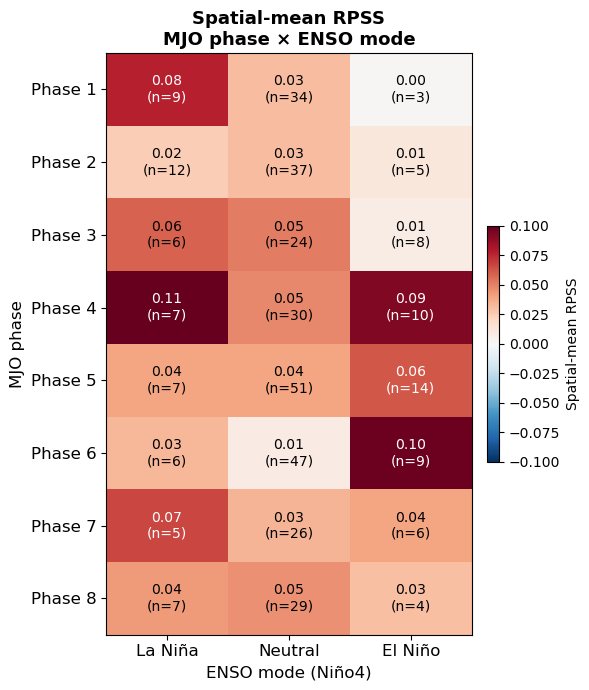

In [45]:
# ── Spatial-mean RPSS for all 24 combinations ─────────────────────
import itertools

enso_modes  = [-1, 0, 1]
enso_labels = {-1: "La Niña", 0: "Neutral", 1: "El Niño"}
grid = np.full((8, 3), np.nan)   # rows=phases, cols=ENSO modes
n_grid = np.zeros((8, 3), dtype=int)

for pi, phase in enumerate(range(1, 9)):
    for ei, mode in enumerate(enso_modes):
        mask_t = ((phase_da == phase) & (enso4_da == mode)).values
        n = mask_t.sum()
        n_grid[pi, ei] = n
        if n < 3:
            continue
        rps_m = xskillscore.rps(obs_r.isel(T=mask_t), fcast.isel(T=mask_t),
                                dim='T', category_edges=None, input_distributions='p')
        rps_c = xskillscore.rps(obs_r.isel(T=mask_t), climo.isel(T=mask_t),
                                dim='T', category_edges=None, input_distributions='p')
        rpss_combo = (1 - rps_m / rps_c).where(~land_mask)
        grid[pi, ei] = float(rpss_combo.mean().values)

fig, ax = plt.subplots(figsize=(6, 7))
im = ax.imshow(grid, aspect='auto', cmap='RdBu_r', vmin=-0.1, vmax=0.1)

ax.set_xticks([0, 1, 2])
ax.set_xticklabels(["La Niña", "Neutral", "El Niño"], fontsize=12)
ax.set_yticks(range(8))
ax.set_yticklabels([f"Phase {p}" for p in range(1, 9)], fontsize=12)
ax.set_xlabel("ENSO mode (Niño4)", fontsize=12)
ax.set_ylabel("MJO phase", fontsize=12)
ax.set_title("Spatial-mean RPSS\nMJO phase × ENSO mode", fontsize=13, fontweight="bold")

# annotate cells with RPSS value and sample size
for pi in range(8):
    for ei in range(3):
        val = grid[pi, ei]
        n   = n_grid[pi, ei]
        txt = f"{val:.2f}\n(n={n})" if not np.isnan(val) else f"n={n}"
        col = "white" if abs(val) > 0.06 else "black" if not np.isnan(val) else "0.5"
        ax.text(ei, pi, txt, ha='center', va='center', fontsize=10, color=col)

plt.colorbar(im, ax=ax, orientation='vertical', label='Spatial-mean RPSS', fraction=0.03, pad=0.04)
plt.tight_layout()
plt.savefig("figures/RPSS drivers/RPSS_MJO_ENSO_heatmap.pdf", dpi=300, bbox_inches="tight")
plt.show()


Sample sizes:
  El Niño + active MJO: n=31
  Neutral + active MJO: n=111
  La Niña + active MJO: n=27
  All active MJO: n=169
  All dates: n=396


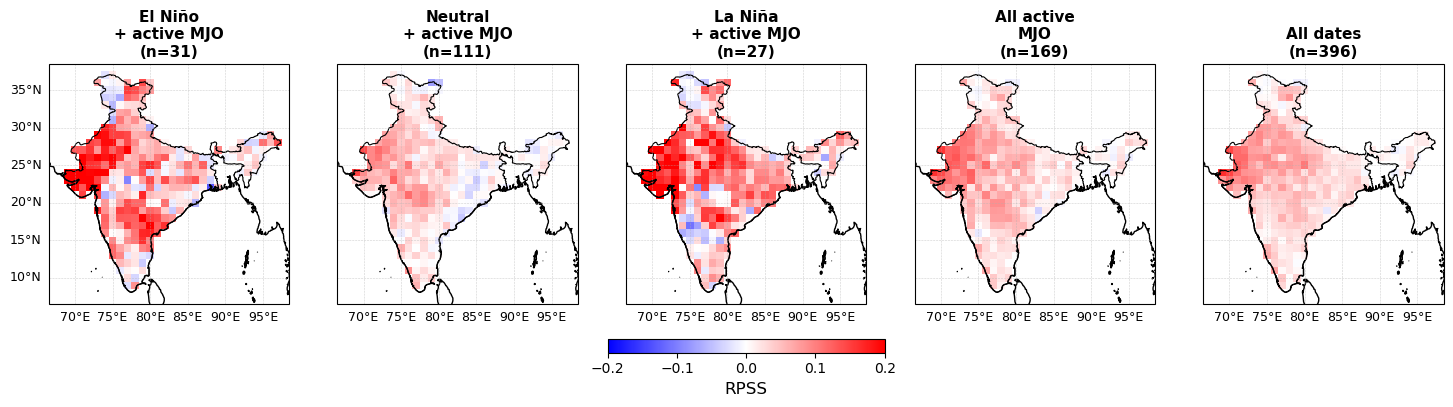

In [46]:
# ── Active MJO summary: 3 regimes × active phases ─────────────────
# Regimes: El Niño + active MJO, La Niña + active MJO, Neutral + active MJO

regimes = {
    "El Niño\n+ active MJO":  (enso4_da ==  1) & active_da,
    "Neutral\n+ active MJO":  (enso4_da ==  0) & active_da,
    "La Niña\n+ active MJO":  (enso4_da == -1) & active_da,
    "All active\nMJO":         active_da,
    "All dates":               xr.ones_like(enso4_da, dtype=bool),
}

regime_rpss = {}
for label, mask_da in regimes.items():
    mask_t = mask_da.values
    if mask_t.sum() < 3:
        regime_rpss[label] = np.nan
        continue
    rps_m = xskillscore.rps(obs_r.isel(T=mask_t), fcast.isel(T=mask_t),
                            dim='T', category_edges=None, input_distributions='p')
    rps_c = xskillscore.rps(obs_r.isel(T=mask_t), climo.isel(T=mask_t),
                            dim='T', category_edges=None, input_distributions='p')
    regime_rpss[label] = (1 - rps_m / rps_c).where(~land_mask)

print("Sample sizes:")
for label, mask_da in regimes.items():
    print(f"  {label.replace(chr(10),' ')}: n={int(mask_da.values.sum())}")

# ── Plot: 1×5 maps ────────────────────────────────────────────────
labels = list(regime_rpss.keys())
fig, axes = plt.subplots(nrows=1, ncols=len(labels), figsize=(18, 4.5),
                         subplot_kw={"projection": ccrs.PlateCarree()})
mappable = None

for i, label in enumerate(labels):
    ax  = axes[i]
    val = regime_rpss[label]
    n   = int(regimes[label].values.sum())

    if isinstance(val, float) and np.isnan(val):
        ax.set_visible(False)
        continue

    im = val.plot(ax=ax, transform=ccrs.PlateCarree(),
                  cmap='bwr', vmin=-0.2, vmax=0.2, add_colorbar=False)
    if mappable is None:
        mappable = im

    ax.coastlines()
    reader = cartopy.io.shapereader.Reader('shapes/indian_borders.shp')
    ax.add_geometries(reader.geometries(), ccrs.PlateCarree(),
                      facecolor='none', edgecolor='black', linewidth=0.8)
    ax.set_title(f"{label}\n(n={n})", fontsize=11, fontweight="bold", pad=5)

    gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.4, alpha=0.6)
    gl.top_labels = False; gl.right_labels = False
    if i > 0: gl.left_labels = False
    gl.xlabel_style = {"size": 9}; gl.ylabel_style = {"size": 9}

cbar = fig.colorbar(mappable, ax=axes, orientation="horizontal",
                    fraction=0.04, pad=0.1)
cbar.set_label("RPSS", fontsize=12)
plt.savefig("figures/RPSS drivers/RPSS_MJO_active_ENSO.pdf", dpi=300, bbox_inches="tight")
plt.show()
